# Random Forest — Predicción de consumo mensual del Metro de Medellín

Versión enfocada **solo en Random Forest** (el mejor modelo en el notebook de árboles), con dos diferencias
respecto a aquel:

1. **Búsqueda de hiperparámetros guiada** (no aleatoria): parte del **mejor RF conocido**
   (`RF_BEST_KNOWN`, MAPE CV ≈ 5.48 %) y refina su vecindario con **Optuna (TPE)**, encolando ese punto
   como primer trial — de modo que el resultado **nunca empeora** el punto de partida.
2. El eje de comparación de todo el notebook es **default vs tuneado** (en lugar de comparar varios modelos).

El resto (splits por fechas alineados con SARIMAX, walk-forward CV mensual, máscara de lags inválidos,
métricas MAE/RMSE/MAPE/R², manejo de meses atípicos, intervalos y exportación) se mantiene igual.


## 0. Setup (Colab)

Optuna no viene preinstalado en Colab. Esta celda lo instala en el kernel actual; el resto de librerías (scikit-learn, scipy, tqdm) ya están disponibles. Si lo corres en un entorno donde Optuna ya existe, la instalación simplemente no hace nada.

In [ ]:
# Colab: instalar Optuna para la búsqueda guiada (idempotente)
%pip install -q optuna

## 1. Imports

In [ ]:
import re, warnings, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from pandas.tseries.offsets import MonthBegin, MonthEnd
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# from google.colab import drive
# drive.mount('/content/drive')
# %cd /content/drive/MyDrive/EAFIT/SIMAT/Metro/data/

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'figure.facecolor': 'white'})

# Optuna para la búsqueda guiada (warm-started). Si no está, se usa un fallback local.
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
    print(f"\u2713 Optuna {optuna.__version__}")
except ImportError:
    HAS_OPTUNA = False
    print("\u2717 Optuna no instalado \u2014 se usar\u00e1 b\u00fasqueda local (fallback). Instalar: pip install optuna")

try:
    from tqdm.auto import tqdm; HAS_TQDM = True
except ImportError:
    HAS_TQDM = False
    class tqdm:
        def __init__(self, iterable=None, **kw): self._it = iterable or []
        def __iter__(self): return iter(self._it)
        def set_postfix(self, **kw): pass

print("\u2713 Librer\u00edas base listas (solo Random Forest)")


✓ Optuna 4.9.0
✓ Librerías base listas (solo Random Forest)


## 2. Configuración global

**Ajusta aquí las fechas, los meses atípicos, los parámetros de la búsqueda y el punto de partida del tuning.**

| Parámetro | Descripción |
|-----------|-------------|
| `TRAIN_START` / `TEST_START` | Fechas de los splits (alineadas con SARIMAX). Test = **un año** (2025). |
| `N_CV_FOLDS` | Meses de walk-forward CV (**un año de validación**) para evaluar cada configuración. Los atípicos se saltan. |
| `N_TRIALS` | Iteraciones de la búsqueda guiada (warm-started desde `RF_BEST_KNOWN`) |
| `SEARCH_N_ESTIMATORS` / `FINAL_N_ESTIMATORS` | Árboles **durante la búsqueda** (pocos, rápido) vs **del modelo final** (todos). El nº de árboles casi no cambia el ranking de estructura, así que buscar con pocos y reentrenar con todos acelera sin perder rigor. |
| `CI_LEVEL` | Nivel de confianza de los intervalos |
| `RF_BEST_KNOWN` | Mejor RF hallado en el notebook de árboles — punto de partida de la búsqueda |
| `DEFAULT_RF` | Baseline por defecto (para el contraste *default vs tuneado*) |


In [ ]:
# ─── AJUSTA AQUÍ ────────────────────────────────────────────────────────────
CSV_PATH    = 'features_mes_completo.csv'   # mismo CSV que la familia SARIMAX / árboles

TRAIN_START = '2018-01'   # Primer mes del train
TEST_START  = '2025-01'   # Primer mes del test  →  test = un año (2025-01 … 2025-12)

N_CV_FOLDS  = 12          # Folds walk-forward de VALIDACIÓN (un año) para evaluar cada config
N_TRIALS    = 15          # Iteraciones de la búsqueda guiada (warm-start incluido)
SEED        = 42
CI_LEVEL    = 0.90        # Nivel de confianza de los intervalos (MAPE mensual y bandas)

# ── Coste del tuning: se busca la ESTRUCTURA con pocos árboles y se reentrena el
#    modelo final con todos. El nº de árboles apenas cambia el ranking de estructura,
#    así que esto acelera mucho la búsqueda de 12 folds sin perder rigor.
SEARCH_N_ESTIMATORS = 200   # árboles durante la búsqueda (rápido)
FINAL_N_ESTIMATORS  = 400   # árboles del modelo tuneado final (evaluación en test)

# Meses atípicos  ->  EXCLUIDOS de todos los promedios / análisis agregado (incluido el CV)
ATYPICAL_MONTHS = ['2025-03', '2025-05', '2025-10', '2025-11', '2025-12']
SHOW_ALL_MONTHS_IN_PLOTS = True

# ── Mejor RandomForest hallado en el notebook de árboles (MAPE CV ≈ 5.48%) ──
#    La búsqueda parte de su ESTRUCTURA y refina su vecindario.
RF_BEST_KNOWN = dict(n_estimators=400, max_depth=None, min_samples_leaf=1,
                     max_features=0.5, max_samples=0.8)

# Baseline por defecto (idéntico al del notebook de árboles) para el contraste default vs tuned
DEFAULT_RF = dict(n_estimators=600, max_depth=None, min_samples_leaf=4,
                  max_features='sqrt', max_samples=1.0)
# ─────────────────────────────────────────────────────────────────────────────

rng = np.random.default_rng(SEED)

# Esquema de color: contraste DEFAULT vs TUNED
VARIANTS = ['default', 'tuned']
VCOLORS  = {'default': '#90A4AE', 'tuned': '#388E3C'}   # gris vs verde RF
RF_COLOR = '#388E3C'

def is_atyp(mes):
    return mes in ATYPICAL_MONTHS

print("Modelo          : RandomForest (único)")
print(f"Train desde     : {TRAIN_START}")
print(f"Test desde      : {TEST_START}  (un año → hasta fin de datos)")
print(f"Folds CV        : {N_CV_FOLDS}  (un año de validación; atípicos excluidos)")
print(f"Trials búsqueda : {N_TRIALS}  (warm-start desde RF_BEST_KNOWN)")
print(f"Árboles         : búsqueda={SEARCH_N_ESTIMATORS}  |  final={FINAL_N_ESTIMATORS}")
print(f"Meses atípicos  : {ATYPICAL_MONTHS}")
print(f"Best-known RF   : {RF_BEST_KNOWN}")


Modelo          : RandomForest (único)
Train desde     : 2018-01
Test desde      : 2025-01  (un año → hasta fin de datos)
Folds CV        : 12  (un año de validación; atípicos excluidos)
Trials búsqueda : 15  (warm-start desde RF_BEST_KNOWN)
Árboles         : búsqueda=200  |  final=400
Meses atípicos  : ['2025-03', '2025-05', '2025-10', '2025-11', '2025-12']
Best-known RF   : {'n_estimators': 400, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_samples': 0.8}


## 3. Carga del dataset

> **Unidades.** `Consumo` está en **kWh de energía diaria** (suma de las 24 lecturas horarias del día).
> La anotación *"Nivel de Tensión (kV): 57,50 ≤ x < 220,00 (Nivel IV)"* del origen de los datos **no es una unidad**:
> describe el **nivel de tensión** del punto de medida (categoría tarifaria CREG; Nivel IV = sub‑transmisión / alta
> tensión), normal para una carga grande como el Metro. No se aplica ninguna conversión — solo se homogenizan las
> etiquetas de los ejes a **kWh**.


In [ ]:
df = pd.read_csv(CSV_PATH, index_col='Fecha', parse_dates=True)
df.index = pd.to_datetime(df.index)
df.sort_index(inplace=True)

# Filtrar desde TRAIN_START (alineación con SARIMAX)
df = df[df.index >= pd.Timestamp(TRAIN_START + '-01')].copy()

print(f"Shape           : {df.shape}")
print(f"Rango de fechas : {df.index.min().date()} \u2192 {df.index.max().date()}")
nulos = df.isnull().sum()
nc = nulos[nulos > 0]
print(f"Columnas con nulos: {len(nc)}" + (f"\n{nc}" if len(nc) else " \u2014 ninguno"))
print(f"\nConsumo \u2014 media: {df['Consumo'].mean():,.0f}  "
      f"std: {df['Consumo'].std():,.0f}  "
      f"min: {df['Consumo'].min():,.0f}  max: {df['Consumo'].max():,.0f}")

Shape           : (2852, 90)
Rango de fechas : 2018-03-12 → 2025-12-31
Columnas con nulos: 0 — ninguno

Consumo — media: 69,212  std: 13,228  min: 19,741  max: 88,671


## 4. Feature sets

In [ ]:
all_cols = df.columns.tolist()
_pat_lag = re.compile(r'^lag_(\d+)$')

CALENDAR_ORDINAL = [c for c in [
    'dia_semana','mes','año','semana_año','es_fin_semana','es_festivo',
    'dia_antes_festivo','dia_despues_festivo','semana_navidad',
    'covid_cuarentena','es_mantenimiento'] if c in all_cols]

def get_lag_cols(cols):
    lags = [(int(_pat_lag.match(c).group(1)), c) for c in cols if _pat_lag.match(c)]
    return [c for _, c in sorted(lags)]

LAG_COLS  = get_lag_cols(all_cols)
ROLL_COLS = sorted([c for c in all_cols
                    if any(c.startswith(p) for p in
                           ['media_roll','std_roll','mediana_roll'])])

FEATURES_TREE = CALENDAR_ORDINAL + LAG_COLS + ROLL_COLS

print(f"Calendar : {len(CALENDAR_ORDINAL)}  |  "
      f"Lags : {len(LAG_COLS)}  |  "
      f"Rolling : {len(ROLL_COLS)}  |  "
      f"TOTAL : {len(FEATURES_TREE)}")
missing = [f for f in FEATURES_TREE if f not in all_cols]
print("\u2713 Todas las features en el CSV." if not missing
      else f"\u26a0 Faltantes: {missing}")

Calendar : 11  |  Lags : 62  |  Rolling : 12  |  TOTAL : 85
✓ Todas las features en el CSV.


## 5. Definición dinámica de splits

- **Train**: desde `TRAIN_START` hasta el día anterior a `TEST_START` (ventana expandible en cada mes de test).
- **Test**: desde `TEST_START` hasta el final del dataset (meses con ≥ 20 días) → **un año** (2025).
- **Folds CV (validación)**: los `N_CV_FOLDS` meses previos al test, **saltando los `ATYPICAL_MONTHS`** y
  alcanzando más atrás si hace falta, para tener un **año completo de validación limpia**.
- **Meses estables**: los meses de test que **no** están en `ATYPICAL_MONTHS`. Todo el análisis
  agregado (promedios, comparaciones, conclusiones) se hace **solo sobre estos**.


In [ ]:
def month_row_count(period):
    start = pd.Timestamp(str(period) + '-01')
    end   = start + MonthEnd(1)
    return len(df[(df.index >= start) & (df.index <= end)])

test_start = pd.Timestamp(TEST_START + '-01')

# ── Meses de test: desde TEST_START hasta fin, con ≥ 20 días ──────────────────
p = test_start.to_period('M')
last_period = df.index.max().to_period('M')
TEST_MONTHS = []
while p <= last_period:
    if month_row_count(p) >= 20:
        TEST_MONTHS.append(str(p))
    p += 1
if not TEST_MONTHS:
    raise ValueError(f"No hay meses completos de test desde {TEST_START}. Ajusta TEST_START.")

# ── Folds CV (N_CV_FOLDS meses antes del test, dentro del train, SALTANDO atípicos) ──
p = (test_start - MonthBegin(1)).to_period('M')
CV_MONTHS = []
while len(CV_MONTHS) < N_CV_FOLDS:
    mes = str(p)
    if month_row_count(p) >= 20 and mes not in ATYPICAL_MONTHS:
        CV_MONTHS.insert(0, mes)
    p -= 1

# ── Meses estables vs atípicos ────────────────────────────────────────────────
STABLE_MONTHS   = [m for m in TEST_MONTHS if m not in ATYPICAL_MONTHS]
ATYP_IN_TEST    = [m for m in TEST_MONTHS if m in ATYPICAL_MONTHS]
ANALYSIS_MONTHS = STABLE_MONTHS                                   # base de TODO promedio
PLOT_MONTHS     = TEST_MONTHS if SHOW_ALL_MONTHS_IN_PLOTS else STABLE_MONTHS

pre_test = df[df.index < test_start]

print("=" * 64)
print(f"  Dataset completo : {df.index.min().date()} → {df.index.max().date()}")
print(f"  Train (pre-test) : {pre_test.index.min().date()} → {pre_test.index.max().date()}  ({len(pre_test)} días)")
print(f"  Folds CV ({len(CV_MONTHS)} m.) : {CV_MONTHS[0]} → {CV_MONTHS[-1]}  (dentro del train, atípicos saltados)")
print(f"  Test  ({len(TEST_MONTHS)} m.) : {TEST_MONTHS[0]} → {TEST_MONTHS[-1]}")
print(f"  → Estables ({len(STABLE_MONTHS)}) : {STABLE_MONTHS}")
print(f"  → Atípicos ({len(ATYP_IN_TEST)}) : {ATYP_IN_TEST}")
print("=" * 64)


  Dataset completo : 2018-03-12 → 2025-12-31
  Train (pre-test) : 2018-03-12 → 2024-12-31  (2487 días)
  Folds CV (12 m.) : 2024-01 → 2024-12  (dentro del train, atípicos saltados)
  Test  (12 m.) : 2025-01 → 2025-12
  → Estables (7) : ['2025-01', '2025-02', '2025-04', '2025-06', '2025-07', '2025-08', '2025-09']
  → Atípicos (5) : ['2025-03', '2025-05', '2025-10', '2025-11', '2025-12']


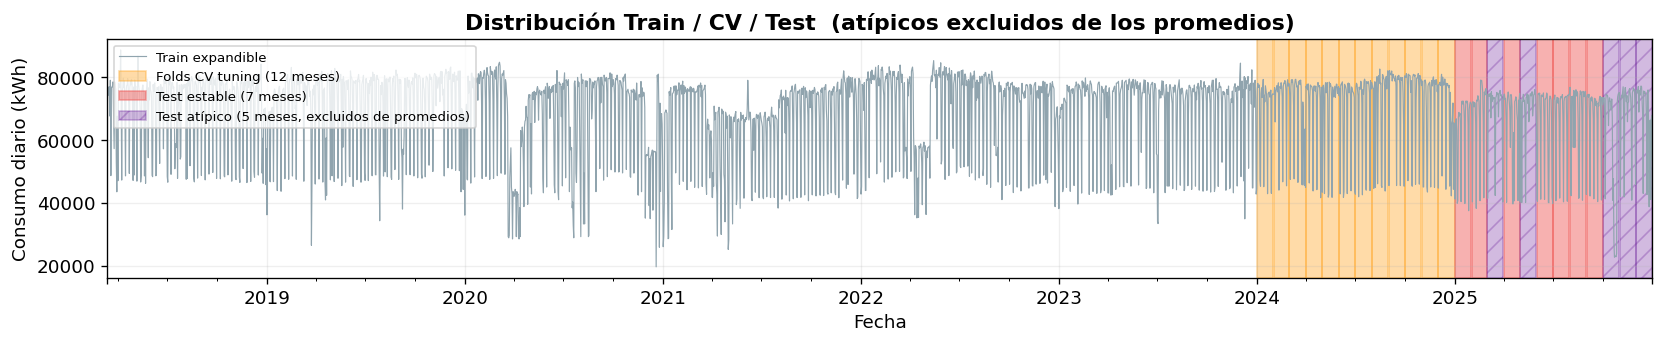

In [ ]:
# ── Visualización del split ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3))
df['Consumo'].plot(ax=ax, lw=0.7, color='#90A4AE', label='Train expandible')

for mes in CV_MONTHS:
    s = pd.Timestamp(f'{mes}-01'); e = s + MonthEnd(1)
    ax.axvspan(s, e, color='#FFA726', alpha=0.40)
ax.axvspan(0, 0, color='#FFA726', alpha=0.40, label=f'Folds CV tuning ({N_CV_FOLDS} meses)')

for mes in STABLE_MONTHS:
    s = pd.Timestamp(f'{mes}-01'); e = s + MonthEnd(1)
    ax.axvspan(s, e, color='#EF5350', alpha=0.45)
ax.axvspan(0, 0, color='#EF5350', alpha=0.45, label=f'Test estable ({len(STABLE_MONTHS)} meses)')

for mes in ATYP_IN_TEST:
    s = pd.Timestamp(f'{mes}-01'); e = s + MonthEnd(1)
    ax.axvspan(s, e, color='#6A1B9A', alpha=0.30, hatch='//')
ax.axvspan(0, 0, color='#6A1B9A', alpha=0.30, hatch='//',
           label=f'Test atípico ({len(ATYP_IN_TEST)} meses, excluidos de promedios)')

ax.set_title('Distribución Train / CV / Test  (atípicos excluidos de los promedios)',
             fontweight='bold')
ax.set_ylabel('Consumo diario (kWh)'); ax.legend(loc='upper left', fontsize=8); ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('split_overview_arboles.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Funciones auxiliares

- `mask_invalid_lags`: anula `lag_k` cuando `k < día del mes` (no disponibles en producción).
- `compute_metrics`: MAE, RMSE, MAPE (%), R² (idénticas al resto de la familia).
- `fit_predict_rf`: imputa medias y ajusta un `RandomForestRegressor` (guarda el imputer para reuso en las bandas).
- `cv_score_rf`: walk-forward CV mensual sobre `CV_MONTHS`; retorna **media, std y mediana** del MAPE entre folds.


In [ ]:
def mask_invalid_lags(X_test: pd.DataFrame) -> pd.DataFrame:
    """Anula lag_k donde k < día del mes (no disponibles en producción)."""
    X_m = X_test.copy()
    lag_info = {c: int(_pat_lag.match(c).group(1))
                for c in X_test.columns if _pat_lag.match(c)}
    for date in X_m.index:
        N = date.day
        for col, k in lag_info.items():
            if k < N:
                X_m.loc[date, col] = np.nan
    return X_m


def compute_metrics(y_true, y_pred):
    """Calcula MAE, RMSE, MAPE y R² (idéntico al notebook SARIMAX)."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    r2   = r2_score(y_true, y_pred)
    return {'MAE': round(mae, 2), 'RMSE': round(rmse, 2),
            'MAPE (%)': round(mape, 4), 'R²': round(r2, 4)}


def fit_predict_rf(params, X_train, y_train, X_test_masked):
    """Imputa medias y ajusta RandomForest. Retorna (preds, model) con model._imputer guardado."""
    imp = SimpleImputer(strategy='mean')
    Xtr = imp.fit_transform(X_train)
    Xte = imp.transform(X_test_masked)
    m = RandomForestRegressor(**params, n_jobs=-1, random_state=SEED)
    m.fit(Xtr, y_train)
    m._imputer = imp
    return m.predict(Xte), m


def cv_score_rf(params, cv_months, trial=None):
    """
    Walk-forward CV mensual dentro del train. Para cada mes en cv_months: entrena en todo lo
    anterior y predice ese mes. Retorna dict con MAPE por fold y estadísticos entre folds:
      'mean' (criterio de selección), 'std', 'median', 'folds'.
    Si se pasa `trial` (Optuna), reporta la media acumulada del MAPE fold a fold y habilita el
    PRUNING (corta configuraciones que ya van claramente peor que la mediana, ahorrando folds).
    """
    mapes = []
    for step, mes in enumerate(cv_months):
        cutoff = pd.Timestamp(f'{mes}-01'); end = cutoff + MonthEnd(1)
        tr  = df[df.index < cutoff]
        val = df[(df.index >= cutoff) & (df.index <= end)]
        if len(tr) < 365 or len(val) == 0:
            continue
        Xtr, ytr = tr[FEATURES_TREE], tr['Consumo']
        Xv_m, yv = mask_invalid_lags(val[FEATURES_TREE]), val['Consumo']
        try:
            preds, _ = fit_predict_rf(params, Xtr, ytr, Xv_m)
            mapes.append(compute_metrics(yv.values, preds)['MAPE (%)'])
        except Exception:
            mapes.append(999.0)
        # ── Pruning de Optuna: reporta media acumulada y corta si should_prune() ──
        if trial is not None:
            trial.report(float(np.mean(mapes)), step)
            if trial.should_prune():
                raise optuna.TrialPruned()
    mapes = np.array(mapes, dtype=float)
    if len(mapes) == 0:
        return {'mean': 999.0, 'std': 0.0, 'median': 999.0, 'folds': []}
    return {'mean': float(np.mean(mapes)),
            'std':  float(np.std(mapes, ddof=1)) if len(mapes) > 1 else 0.0,
            'median': float(np.median(mapes)),
            'folds': mapes.tolist()}


print("✓ Funciones auxiliares definidas.")


✓ Funciones auxiliares definidas.


## 7. Búsqueda guiada de hiperparámetros (warm-started desde el mejor RF conocido)

En vez de un random search "a ciegas", partimos de la **estructura del mejor RandomForest hallado en el notebook
de árboles** (`RF_BEST_KNOWN`, MAPE CV ≈ 5.48 %) y exploramos su **vecindario** para intentar mejorarlo:

- El espacio de búsqueda está **centrado** en `RF_BEST_KNOWN` y cubre solo la **estructura** (`max_depth`,
  `min_samples_leaf`, `max_features`, `max_samples`).
- **Se busca con pocos árboles** (`SEARCH_N_ESTIMATORS`) y el **modelo final se reentrena con todos**
  (`FINAL_N_ESTIMATORS`). El ranking de estructura es estable frente al nº de árboles, así que esto
  **acelera mucho** la validación de un año sin perder rigor.
- **Optuna (TPE)** para el muestreo bayesiano, con **`MedianPruner`**: reporta la media del MAPE fold a fold y
  **corta las configuraciones que ya van claramente peor** antes de gastar los 12 folds completos.
- El primer trial es **exactamente** `RF_BEST_KNOWN` (`enqueue_trial`) y está protegido del pruning
  (`n_startup_trials`), así el resultado **nunca es peor** que el punto de partida.
- El criterio sigue siendo el **MAPE medio de walk-forward CV**; se reportan también **std** y **mediana**.

> Con `N_TRIALS=15`, `N_CV_FOLDS=12` y `SEARCH_N_ESTIMATORS=200`, el número total de árboles entrenados en la
> búsqueda es **menor** que en la versión original (25 trials × 6 folds × 400 árboles), pese a **doblar** los
> meses de validación — gracias a los árboles reducidos y al pruning.


In [ ]:
# Espacio de ESTRUCTURA centrado en RF_BEST_KNOWN (sin n_estimators: se busca con pocos árboles).
# max_depth = 0 codifica None (para las categóricas de Optuna).
SPACE = {
    'max_depth'       : [0, 25, 30, 40, 50],          # 0 -> None
    'min_samples_leaf': [1, 2, 3],
    'max_features'    : [0.33, 0.40, 0.50, 0.60, 0.70],
    'max_samples'     : [0.70, 0.80, 0.90, 1.00],
}

def _decode(raw):
    """raw (estructura codificada) -> params de estructura (sin n_estimators)."""
    return dict(
        max_depth        = (None if raw['max_depth'] in (0, None) else int(raw['max_depth'])),
        min_samples_leaf = int(raw['min_samples_leaf']),
        max_features     = float(raw['max_features']),
        max_samples      = float(raw['max_samples']),
    )

def _encode(p):
    """params de estructura -> codificado (para enqueue_trial del warm-start)."""
    return {'max_depth': 0 if p['max_depth'] is None else p['max_depth'],
            'min_samples_leaf': p['min_samples_leaf'],
            'max_features': p['max_features'],
            'max_samples': p['max_samples']}

def _with_search_trees(struct):
    """Estructura -> params completos para la BÚSQUEDA (pocos árboles)."""
    return dict(struct, n_estimators=SEARCH_N_ESTIMATORS)

tuning_rows = []
t0 = time.time()

if HAS_OPTUNA:
    def objective(trial):
        raw = {k: trial.suggest_categorical(k, v) for k, v in SPACE.items()}
        struct = _decode(raw)
        trial.set_user_attr('struct', struct)      # se guarda aunque el trial acabe pruned
        cvs = cv_score_rf(_with_search_trees(struct), CV_MONTHS, trial=trial)
        trial.set_user_attr('cv_std', cvs['std'])
        trial.set_user_attr('cv_median', cvs['median'])
        return cvs['mean']

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3))
    study.enqueue_trial(_encode(RF_BEST_KNOWN))            # trial 1 = mejor conocido (warm-start)

    for it in tqdm(range(N_TRIALS), desc='RF Optuna'):
        study.optimize(objective, n_trials=1, catch=(Exception,))
        t = study.trials[-1]
        struct = t.user_attrs.get('struct', {})
        is_pruned = (t.state == optuna.trial.TrialState.PRUNED)
        tuning_rows.append({'trial': it+1, 'cv_mape': t.value,
                            'cv_std': t.user_attrs.get('cv_std'),
                            'cv_median': t.user_attrs.get('cv_median'),
                            'pruned': bool(is_pruned),
                            'n_estimators': SEARCH_N_ESTIMATORS, **struct})
        if (it+1) % 5 == 0 or (it+1) == N_TRIALS:
            best = study.best_value if study.best_trial else float('nan')
            vtxt = f"{t.value:.3f}%" if t.value is not None else "pruned "
            print(f"  trial {it+1:>3}/{N_TRIALS}  MAPE={vtxt}  mejor={best:.3f}%  t={time.time()-t0:.0f}s")

    bt = study.best_trial
    best_struct = bt.user_attrs['struct']
    best_params_rf = dict(best_struct, n_estimators=FINAL_N_ESTIMATORS)   # modelo final con todos los árboles
    best_stats  = {'mean': bt.value, 'std': bt.user_attrs['cv_std'], 'median': bt.user_attrs['cv_median']}
    k0 = study.trials[0]
    known_stats = {'mean': k0.value, 'std': k0.user_attrs['cv_std'], 'median': k0.user_attrs['cv_median']}

else:
    def _sample_local():
        return _decode({k: rng.choice(v) for k, v in SPACE.items()})
    struct0 = _decode(_encode(RF_BEST_KNOWN))
    cands = [struct0] + [_sample_local() for _ in range(N_TRIALS - 1)]
    best_struct, best_stats, known_stats = None, {'mean': np.inf}, None
    for it, struct in enumerate(tqdm(cands, desc='RF local')):
        cvs = cv_score_rf(_with_search_trees(struct), CV_MONTHS)
        tuning_rows.append({'trial': it+1, 'cv_mape': cvs['mean'],
                            'cv_std': cvs['std'], 'cv_median': cvs['median'],
                            'pruned': False, 'n_estimators': SEARCH_N_ESTIMATORS, **struct})
        if it == 0:
            known_stats = {'mean': cvs['mean'], 'std': cvs['std'], 'median': cvs['median']}
        if cvs['mean'] < best_stats['mean']:
            best_stats = {'mean': cvs['mean'], 'std': cvs['std'], 'median': cvs['median']}
            best_struct = struct
        if (it+1) % 5 == 0 or (it+1) == len(cands):
            print(f"  trial {it+1:>3}/{len(cands)}  MAPE={cvs['mean']:.3f}%  "
                  f"mejor={best_stats['mean']:.3f}%  t={time.time()-t0:.0f}s")
    best_params_rf = dict(best_struct, n_estimators=FINAL_N_ESTIMATORS)

tuning_df = pd.DataFrame(tuning_rows)
mejora = known_stats['mean'] - best_stats['mean']

print(f"\n{'='*62}")
print(f"  Búsqueda completada en {(time.time()-t0)/60:.1f} min")
print(f"  (búsqueda con {SEARCH_N_ESTIMATORS} árboles · modelo final con {FINAL_N_ESTIMATORS})")
print(f"  Best-known : MAPE CV = {known_stats['mean']:.3f}%  "
      f"(std {known_stats['std']:.3f} | mediana {known_stats['median']:.3f})")
print(f"  Tuneado    : MAPE CV = {best_stats['mean']:.3f}%  "
      f"(std {best_stats['std']:.3f} | mediana {best_stats['median']:.3f})")
print(f"  Mejora vs best-known: {mejora:+.3f} pp de MAPE")
print(f"  Params tuneados (final): {best_params_rf}")
print(f"{'='*62}")


RF Optuna:   0%|          | 0/15 [00:00<?, ?it/s]

  trial   5/15  MAPE=5.014%  mejor=5.014%  t=1171s
  trial  10/15  MAPE=5.620%  mejor=4.576%  t=2087s
  trial  15/15  MAPE=4.574%  mejor=4.574%  t=3637s

  Búsqueda completada en 60.6 min
  (búsqueda con 200 árboles · modelo final con 400)
  Best-known : MAPE CV = 5.651%  (std 1.020 | mediana 5.764)
  Tuneado    : MAPE CV = 4.574%  (std 0.898 | mediana 4.631)
  Mejora vs best-known: +1.077 pp de MAPE
  Params tuneados (final): {'max_depth': 50, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_samples': 0.7, 'n_estimators': 400}


## 8. Convergencia de la búsqueda

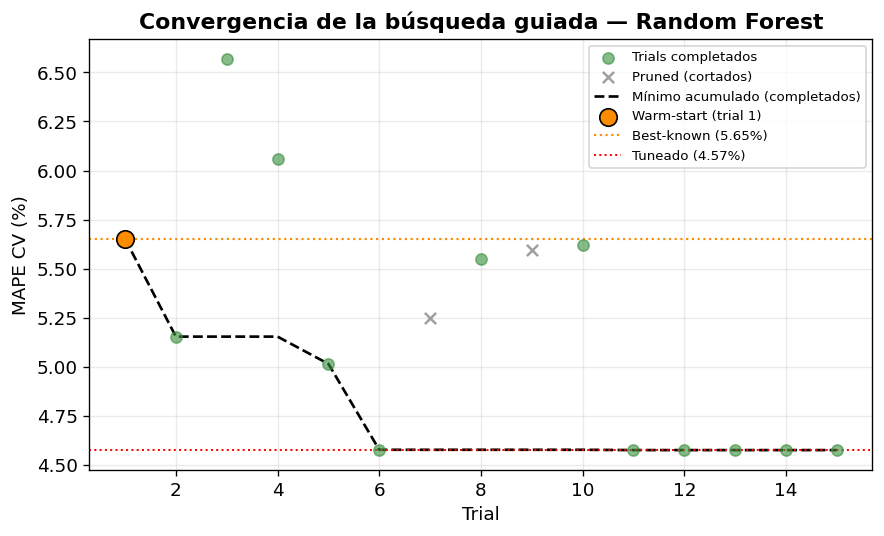

── Hiperparámetros ──
  Default : {'n_estimators': 600, 'max_depth': None, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_samples': 1.0}
  Tuneado : {'max_depth': 50, 'min_samples_leaf': 1, 'max_features': 0.7, 'max_samples': 0.7, 'n_estimators': 400}


In [ ]:
# Los trials pruned conservan un MAPE parcial: se marcan por la columna 'pruned',
# y el mínimo acumulado se calcula SOLO con los trials completados (los elegibles como mejor).
tsort = tuning_df.sort_values('trial')
comp  = tsort[(~tsort['pruned'].fillna(False)) & tsort['cv_mape'].notna()].copy()
prun  = tsort[tsort['pruned'].fillna(False) & tsort['cv_mape'].notna()].copy()
comp['best_so_far'] = comp['cv_mape'].cummin()

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.scatter(comp['trial'], comp['cv_mape'], color=RF_COLOR, alpha=0.6, s=45, zorder=3, label='Trials completados')
if len(prun):
    ax.scatter(prun['trial'], prun['cv_mape'], marker='x', color='gray',
               s=45, alpha=0.75, zorder=3, label='Pruned (cortados)')
ax.plot(comp['trial'], comp['best_so_far'], 'k--', lw=1.6, label='Mínimo acumulado (completados)')
w1 = tsort[tsort['trial'] == 1]
ax.scatter(w1['trial'], w1['cv_mape'], color='#FB8C00', s=110, zorder=5,
           edgecolor='k', label='Warm-start (trial 1)')
ax.axhline(known_stats['mean'], color='#FB8C00', lw=1.3, ls=':', label=f"Best-known ({known_stats['mean']:.2f}%)")
ax.axhline(best_stats['mean'],  color='red',     lw=1.2, ls=':', label=f"Tuneado ({best_stats['mean']:.2f}%)")
ax.set_xlabel('Trial'); ax.set_ylabel('MAPE CV (%)')
ax.set_title('Convergencia de la búsqueda guiada — Random Forest', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('tuning_convergencia_rf.png', dpi=150, bbox_inches='tight')
plt.show()

print("── Hiperparámetros ──")
print(f"  Default : {DEFAULT_RF}")
print(f"  Tuneado : {best_params_rf}")


## 9. Evaluación final en test — Default vs Tuneado

Para cada mes de test se entrena RandomForest con **todo el train anterior a ese mes** (ventana expandible),
en dos variantes: **default** (`DEFAULT_RF`) y **tuneado** (`best_params_rf`).


In [ ]:
def eval_variants():
    res = {}
    for mes in TEST_MONTHS:
        cutoff = pd.Timestamp(f'{mes}-01'); end = cutoff + MonthEnd(1)
        train = df[df.index < cutoff]
        test  = df[(df.index >= cutoff) & (df.index <= end)]
        Xtr, ytr = train[FEATURES_TREE], train['Consumo']
        Xte, yte = test[FEATURES_TREE],  test['Consumo']
        Xte_m = mask_invalid_lags(Xte)
        res[mes] = {}
        for variant, params in [('default', DEFAULT_RF), ('tuned', best_params_rf)]:
            preds, model = fit_predict_rf(params, Xtr, ytr, Xte_m)
            res[mes][variant] = {'preds': preds, 'real': yte.values, 'dates': yte.index,
                                 'metrics': compute_metrics(yte.values, preds), 'model': model}
        print(f"  \u2713 {mes} evaluado (default + tuned)")
    return res

results = eval_variants()
print("\n\u2713 Evaluaci\u00f3n completa.")


  ✓ 2025-01 evaluado (default + tuned)
  ✓ 2025-02 evaluado (default + tuned)
  ✓ 2025-03 evaluado (default + tuned)
  ✓ 2025-04 evaluado (default + tuned)
  ✓ 2025-05 evaluado (default + tuned)
  ✓ 2025-06 evaluado (default + tuned)
  ✓ 2025-07 evaluado (default + tuned)
  ✓ 2025-08 evaluado (default + tuned)
  ✓ 2025-09 evaluado (default + tuned)
  ✓ 2025-10 evaluado (default + tuned)
  ✓ 2025-11 evaluado (default + tuned)
  ✓ 2025-12 evaluado (default + tuned)

✓ Evaluación completa.


## 10. Predicción vs Real — Default vs Tuneado

Cada panel muestra el consumo real y las dos variantes de RandomForest. Los meses atípicos van marcados con **⚠**
y **no entran** en los promedios de las secciones siguientes.


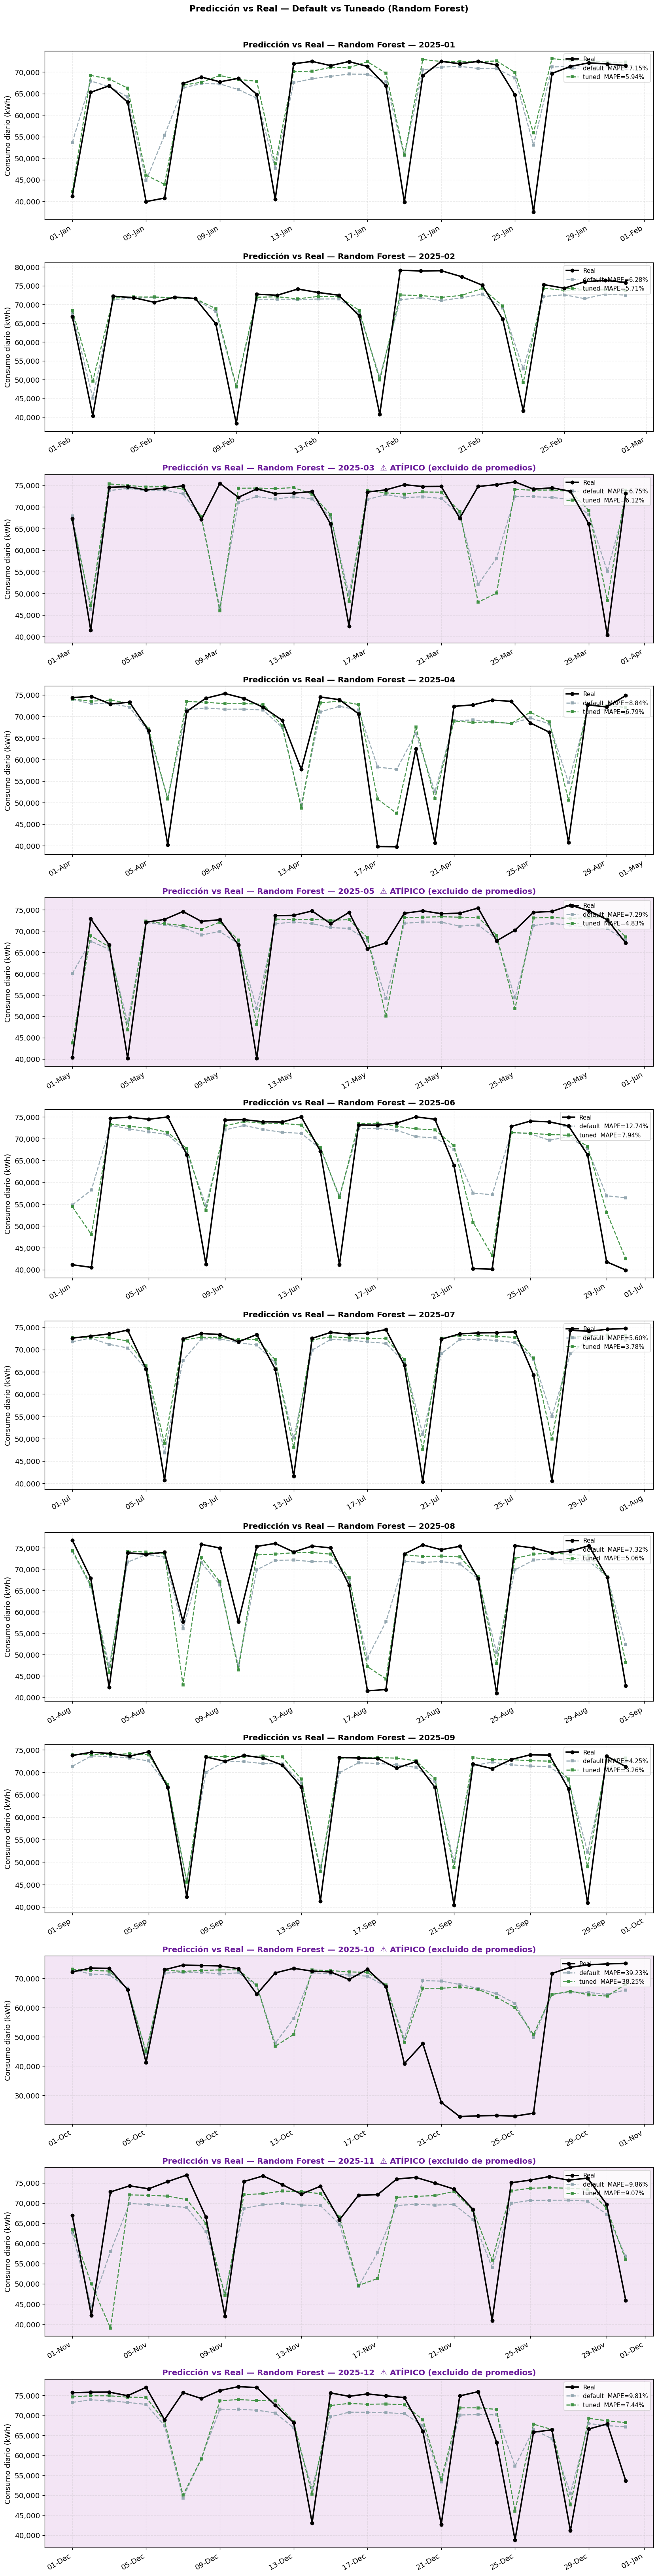

In [ ]:
n = len(PLOT_MONTHS)
fig, axes = plt.subplots(n, 1, figsize=(14, 4.5*n), sharex=False)
if n == 1: axes = [axes]

for ax, mes in zip(axes, PLOT_MONTHS):
    dates = results[mes]['tuned']['dates']
    real  = results[mes]['tuned']['real']
    ax.plot(dates, real, 'k-o', lw=2.2, ms=5, label='Real', zorder=6)
    for variant in VARIANTS:
        p    = results[mes][variant]['preds']
        mape = results[mes][variant]['metrics']['MAPE (%)']
        ax.plot(dates, p, '--s', ms=4, lw=1.6, color=VCOLORS[variant], alpha=0.9,
                label=f"{variant}  MAPE={mape:.2f}%")
    tag = '  \u26a0 AT\u00cdPICO (excluido de promedios)' if is_atyp(mes) else ''
    ax.set_title(f'Predicci\u00f3n vs Real \u2014 Random Forest \u2014 {mes}{tag}',
                 fontsize=12, fontweight='bold', color=('#6A1B9A' if is_atyp(mes) else 'black'))
    ax.set_ylabel('Consumo diario (kWh)')
    ax.legend(loc='upper right', fontsize=9); ax.grid(True, alpha=0.25, ls='--')
    if is_atyp(mes): ax.set_facecolor('#F3E5F5')
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d-%b'))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Predicci\u00f3n vs Real \u2014 Default vs Tuneado (Random Forest)',
             fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('pred_vs_real_rf.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Degradación del error con el horizonte — Default vs Tuneado

Error absoluto por día dentro del mes (cómo crece a medida que avanza el horizonte de pronóstico).


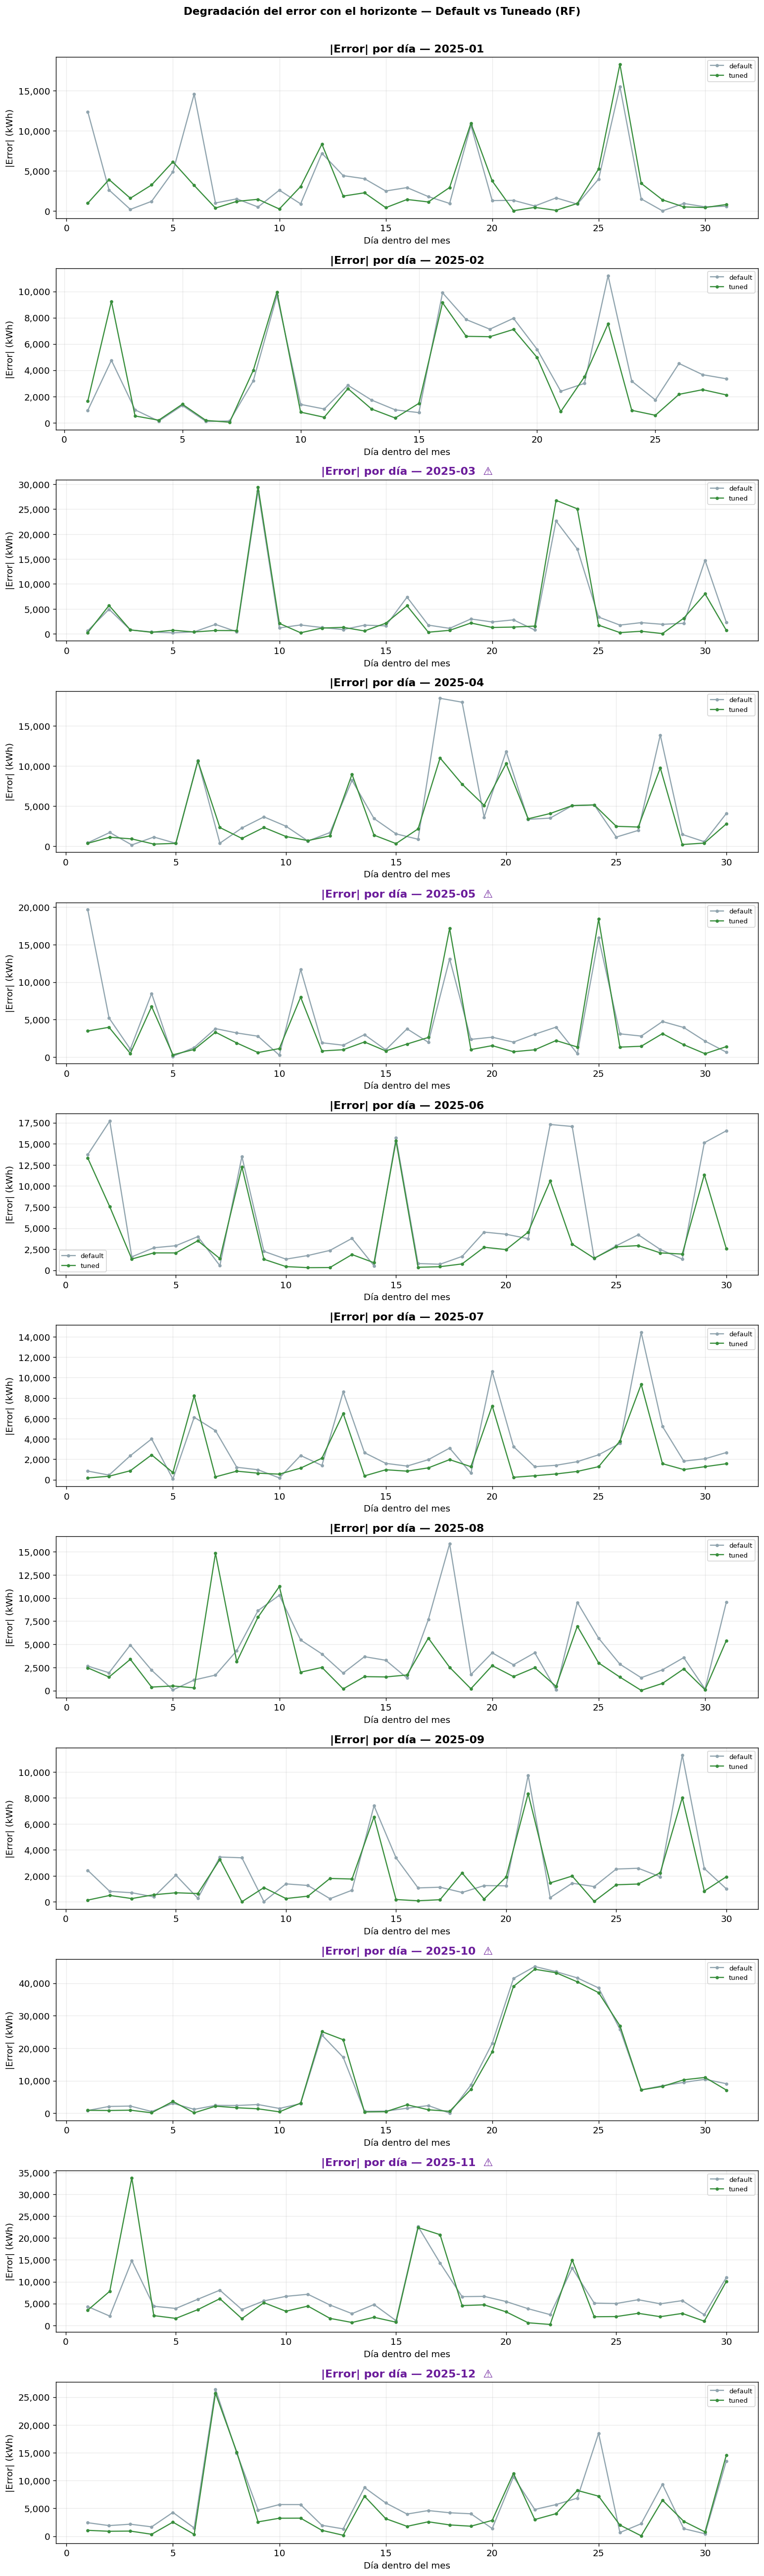

In [ ]:
n = len(PLOT_MONTHS)
fig, axes = plt.subplots(n, 1, figsize=(13, 3.6*n), sharex=False)
if n == 1: axes = [axes]

for ax, mes in zip(axes, PLOT_MONTHS):
    dates = results[mes]['tuned']['dates']
    dom   = np.array([d.day for d in dates])
    for variant in VARIANTS:
        r  = results[mes][variant]
        ae = np.abs(np.asarray(r['real'], float) - np.asarray(r['preds'], float))
        ax.plot(dom, ae, '-o', ms=3, lw=1.4, color=VCOLORS[variant], label=variant)
    tag = '  \u26a0' if is_atyp(mes) else ''
    ax.set_title(f'|Error| por d\u00eda \u2014 {mes}{tag}', fontweight='bold',
                 color=('#6A1B9A' if is_atyp(mes) else 'black'))
    ax.set_xlabel('D\u00eda dentro del mes'); ax.set_ylabel('|Error| (kWh)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.25)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Degradaci\u00f3n del error con el horizonte \u2014 Default vs Tuneado (RF)',
             fontsize=13, fontweight='bold', y=1.003)
plt.tight_layout()
plt.savefig('error_horizonte_rf.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Tabla comparativa — Default vs Tuneado

In [ ]:
def _avg_metrics(variant, meses):
    return pd.DataFrame([results[m][variant]['metrics'] for m in meses]).mean()

rows = []
for mes in TEST_MONTHS:
    for variant in VARIANTS:
        m = results[mes][variant]['metrics']
        rows.append({'Mes': mes, 'At\u00edpico': is_atyp(mes), 'Variante': variant, **m})
metrics_df = pd.DataFrame(rows)

print("\u2550\u2550 M\u00e9tricas por mes (default vs tuned) \u2550\u2550")
print(metrics_df.to_string(index=False))

print("\n\u2500\u2500 Promedio sobre meses ESTABLES \u2500\u2500")
for variant in VARIANTS:
    a = _avg_metrics(variant, STABLE_MONTHS)
    print(f"  {variant:8s}: MAE={a['MAE']:,.0f}  RMSE={a['RMSE']:,.0f}  "
          f"MAPE={a['MAPE (%)']:.2f}%  R\u00b2={a['R\u00b2']:.4f}")


══ Métricas por mes (default vs tuned) ══
    Mes  Atípico Variante      MAE     RMSE  MAPE (%)     R²
2025-01    False  default  3399.02  5371.49    7.1476 0.7979
2025-01    False    tuned  2896.90  4718.02    5.9380 0.8441
2025-02    False  default  3622.07  4813.64    6.2839 0.8409
2025-02    False    tuned  3157.24  4423.04    5.7141 0.8656
2025-03     True  default  4313.29  8024.05    6.7483 0.3194
2025-03     True    tuned  4045.23  8764.51    6.1181 0.1879
2025-04    False  default  4383.09  6671.50    8.8428 0.7005
2025-04    False    tuned  3499.98  4917.00    6.7932 0.8373
2025-05     True  default  4232.56  6267.14    7.2895 0.5981
2025-05     True    tuned  2971.92  5183.63    4.8318 0.7250
2025-06    False  default  5948.19  8525.01   12.7355 0.6470
2025-06    False    tuned  3798.67  5684.89    7.9446 0.8430
2025-07    False  default  3063.17  4360.29    5.5968 0.8404
2025-07    False    tuned  1942.90  3092.21    3.7836 0.9197
2025-08    False  default  4151.25  5432.29

## 13. Comparativa visual — MAPE por mes estable (Default vs Tuneado)

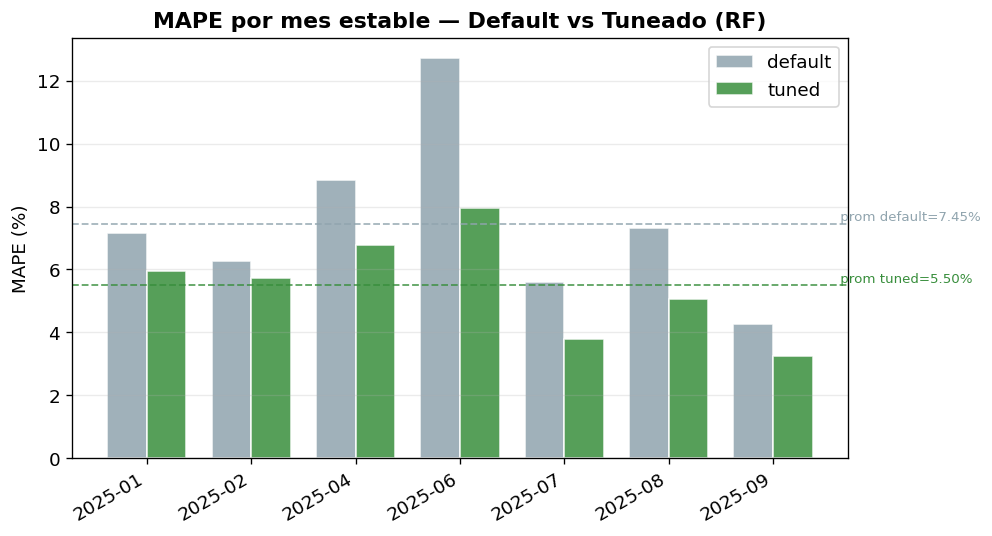

In [ ]:
stable = STABLE_MONTHS
x = np.arange(len(stable)); w = 0.38
fig, ax = plt.subplots(figsize=(max(7, len(stable)*1.2), 4.6))
for k, variant in enumerate(VARIANTS):
    vals = [results[m][variant]['metrics']['MAPE (%)'] for m in stable]
    ax.bar(x + (k-0.5)*w, vals, w, color=VCOLORS[variant], alpha=0.85, label=variant, edgecolor='white')
    avg = float(np.mean(vals))
    ax.axhline(avg, color=VCOLORS[variant], ls='--', lw=1.1, alpha=0.8)
    ax.text(len(stable)-0.4, avg, f' prom {variant}={avg:.2f}%', va='bottom',
            fontsize=8, color=VCOLORS[variant])
ax.set_xticks(x); ax.set_xticklabels(stable, rotation=30, ha='right')
ax.set_ylabel('MAPE (%)')
ax.set_title('MAPE por mes estable \u2014 Default vs Tuneado (RF)', fontweight='bold')
ax.legend(); ax.grid(True, axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig('comparativa_mape_rf.png', dpi=150, bbox_inches='tight')
plt.show()


## 14. Heatmap MAPE — mes × variante

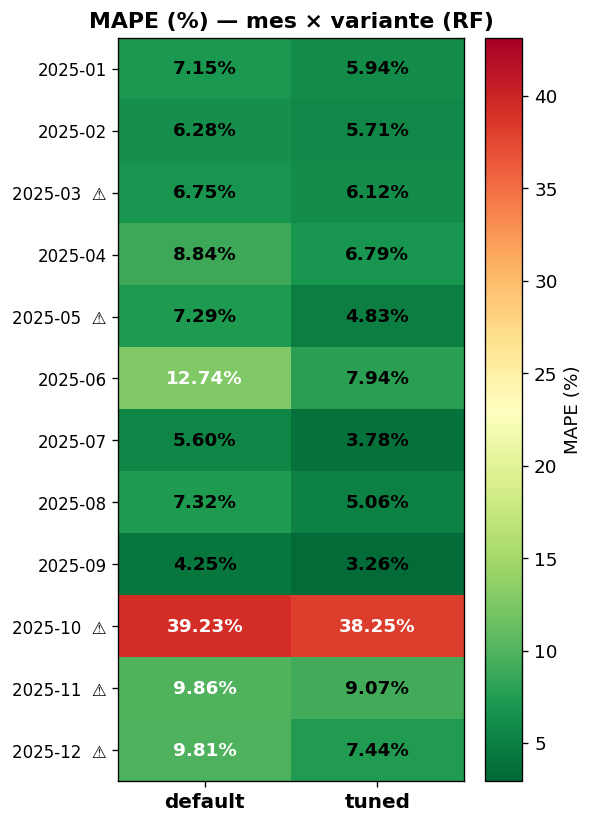

In [ ]:
mat = np.array([[results[m][v]['metrics']['MAPE (%)'] for v in VARIANTS] for m in TEST_MONTHS])
fig, ax = plt.subplots(figsize=(5, max(4, len(TEST_MONTHS)*0.5 + 1)))
im = ax.imshow(mat, cmap='RdYlGn_r', aspect='auto', vmin=mat.min()*0.9, vmax=mat.max()*1.1)
ax.set_xticks(range(len(VARIANTS))); ax.set_xticklabels(VARIANTS, fontsize=12, fontweight='bold')
ylabels = [f'{m}  \u26a0' if is_atyp(m) else m for m in TEST_MONTHS]
ax.set_yticks(range(len(TEST_MONTHS))); ax.set_yticklabels(ylabels, fontsize=10)
mean_val = mat.mean()
for i in range(len(TEST_MONTHS)):
    for j in range(len(VARIANTS)):
        ax.text(j, i, f'{mat[i,j]:.2f}%', ha='center', va='center', fontweight='bold',
                fontsize=11, color='white' if mat[i,j] > mean_val else 'black')
plt.colorbar(im, ax=ax, label='MAPE (%)')
ax.set_title('MAPE (%) \u2014 mes \u00d7 variante (RF)', fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_mape_rf.png', dpi=150, bbox_inches='tight')
plt.show()


## 15. Feature importance — Random Forest tuneado (promedio sobre meses estables)

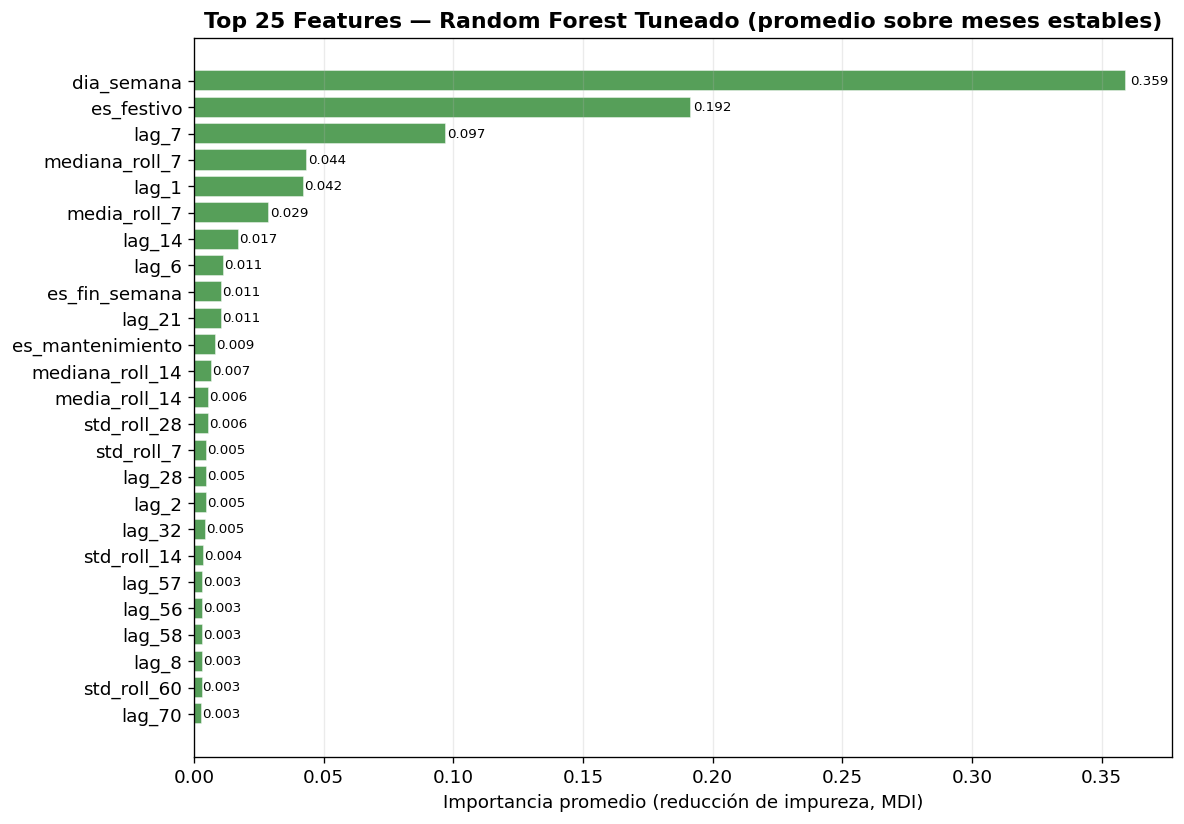

In [ ]:
imps = [pd.Series(results[mes]['tuned']['model'].feature_importances_, index=FEATURES_TREE)
        for mes in STABLE_MONTHS]
avg_imp = pd.concat(imps, axis=1).mean(axis=1).nlargest(25).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(avg_imp.index, avg_imp.values, color=RF_COLOR, alpha=0.85, edgecolor='white')
for bar, v in zip(bars, avg_imp.values):
    ax.text(v*1.005, bar.get_y()+bar.get_height()/2, f'{v:.3f}', va='center', fontsize=8)
ax.set_title('Top 25 Features \u2014 Random Forest Tuneado (promedio sobre meses estables)', fontweight='bold')
ax.set_xlabel('Importancia promedio (reducci\u00f3n de impureza, MDI)')
ax.grid(True, axis='x', alpha=0.25)
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()


## 15b. Feature importance por **permutación** — RF tuneado (out-of-sample, meses estables)

El MDI de la sección anterior se calcula sobre el *entrenamiento* y está sesgado hacia variables continuas y
de muchos valores de corte (lags, rollings), además de repartirse entre variables correlacionadas. Como
complemento, aquí se mide la importancia por **permutación**: cuánto **empeora el MAPE** al barajar cada
variable, evaluado en cada mes **estable de test** (fuera de muestra) y promediado entre esos meses — el
mismo criterio (MAPE) y la misma base (meses estables) que usa el resto del notebook.


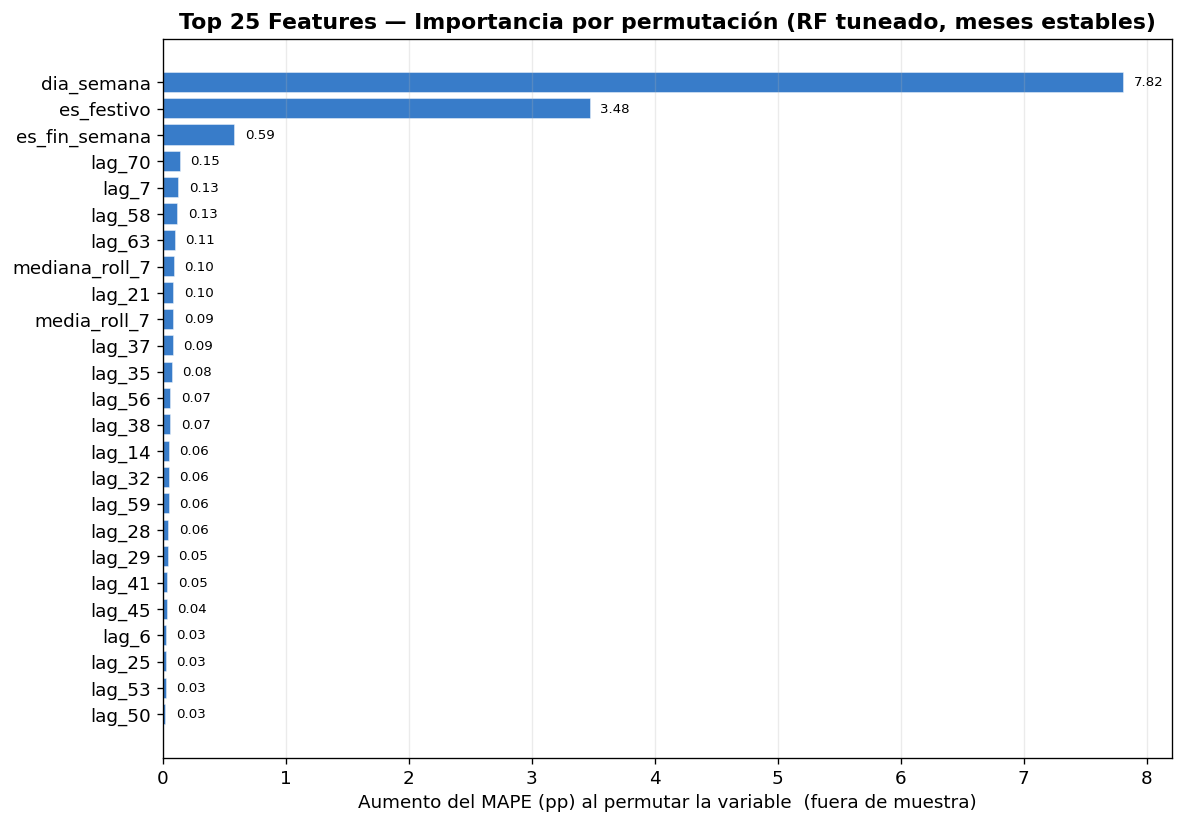

── MDI vs Permutación (top-15 por permutación) ──
                MDI (impureza)  Permutación (ΔMAPE pp)
dia_semana              0.3593                  7.8165
es_festivo              0.1916                  3.4780
es_fin_semana           0.0109                  0.5882
lag_70                  0.0032                  0.1461
lag_7                   0.0971                  0.1329
lag_58                  0.0033                  0.1284
lag_63                  0.0029                  0.1056
mediana_roll_7          0.0436                  0.0968
lag_21                  0.0107                  0.0955
media_roll_7            0.0291                  0.0936
lag_37                  0.0023                  0.0896
lag_35                  0.0019                  0.0827
lag_56                  0.0034                  0.0712
lag_38                  0.0021                  0.0694
lag_14                  0.0172                  0.0588

→ Guardado: feature_importance_perm_rf.csv


In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer

def _neg_mape_score(y_true, y_pred):
    """Score = -MAPE (↑ mejor). La importancia por permutación = caída del score = ΔMAPE (pp)."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    m = y_true != 0
    return -np.mean(np.abs((y_true[m] - y_pred[m]) / y_true[m])) * 100

_mape_scorer = make_scorer(_neg_mape_score)

perm_series = []
for mes in STABLE_MONTHS:
    model = results[mes]['tuned']['model']; imp = model._imputer
    cutoff = pd.Timestamp(f'{mes}-01'); end = cutoff + MonthEnd(1)
    test = df[(df.index >= cutoff) & (df.index <= end)]
    Xte = imp.transform(mask_invalid_lags(test[FEATURES_TREE]))   # mismo pipeline que en la evaluación
    yte = test['Consumo'].to_numpy(float)
    r = permutation_importance(model, Xte, yte, scoring=_mape_scorer,
                               n_repeats=10, random_state=SEED, n_jobs=1)
    perm_series.append(pd.Series(r.importances_mean, index=FEATURES_TREE))

perm_imp = pd.concat(perm_series, axis=1).mean(axis=1)          # ΔMAPE (pp) promedio por variable
perm_top = perm_imp.nlargest(25).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(perm_top.index, perm_top.values, color='#1565C0', alpha=0.85, edgecolor='white')
_xmax = max(perm_top.values.max(), 1e-9)
for bar, v in zip(bars, perm_top.values):
    ax.text(v + _xmax*0.01, bar.get_y()+bar.get_height()/2, f'{v:.2f}', va='center', fontsize=8)
ax.set_title('Top 25 Features — Importancia por permutación (RF tuneado, meses estables)', fontweight='bold')
ax.set_xlabel('Aumento del MAPE (pp) al permutar la variable  (fuera de muestra)')
ax.grid(True, axis='x', alpha=0.25)
plt.tight_layout()
plt.savefig('feature_importance_perm_rf.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Comparación rápida MDI vs permutación (top-15 por permutación) ────────────
mdi_avg = pd.concat(
    [pd.Series(results[m]['tuned']['model'].feature_importances_, index=FEATURES_TREE)
     for m in STABLE_MONTHS], axis=1).mean(axis=1)
cmp_imp = (pd.DataFrame({'MDI (impureza)': mdi_avg, 'Permutación (ΔMAPE pp)': perm_imp})
             .sort_values('Permutación (ΔMAPE pp)', ascending=False).head(15))
print("── MDI vs Permutación (top-15 por permutación) ──")
print(cmp_imp.round(4).to_string())
perm_imp.sort_values(ascending=False).to_csv('feature_importance_perm_rf.csv', header=['perm_dMAPE_pp'])
print("\n→ Guardado: feature_importance_perm_rf.csv")


## 16. APE promedio por horizonte — Default vs Tuneado (meses estables)

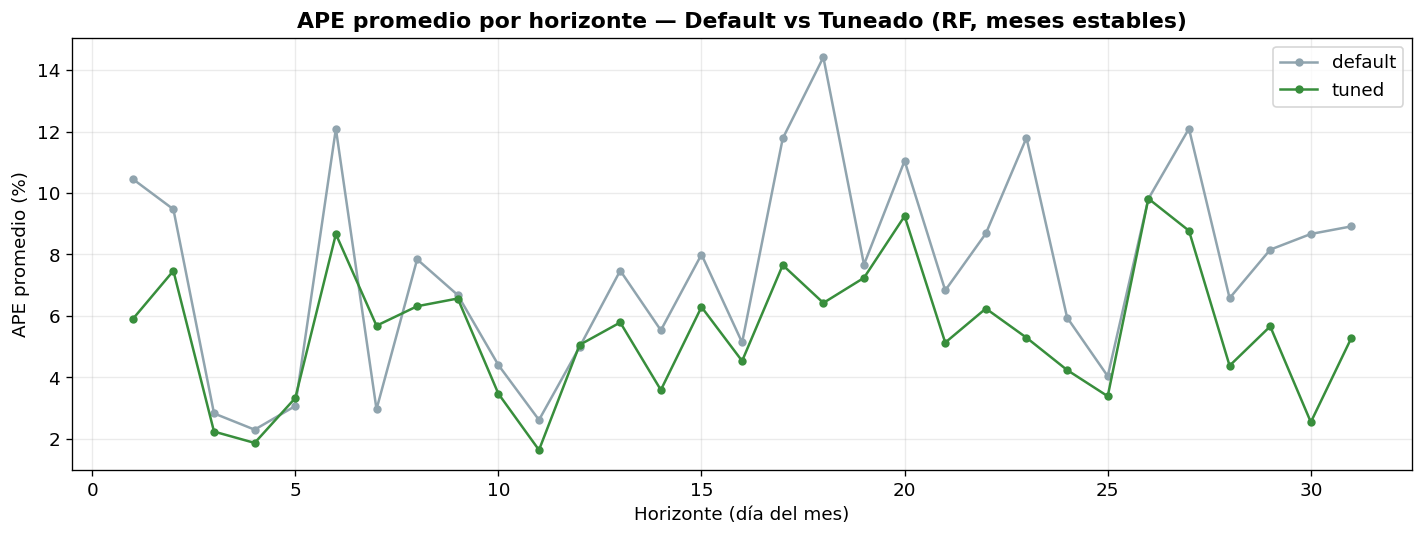

In [ ]:
records = []
for mes in STABLE_MONTHS:
    for variant in VARIANTS:
        r = results[mes][variant]
        for d, rl, pr in zip(r['dates'], np.asarray(r['real'], float), np.asarray(r['preds'], float)):
            if rl != 0:
                records.append({'dom': d.day, 'variant': variant, 'ape': abs(rl-pr)/rl*100})
ape_df = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(12, 4.6))
for variant in VARIANTS:
    g = ape_df[ape_df['variant'] == variant].groupby('dom')['ape'].mean()
    ax.plot(g.index, g.values, '-o', ms=4, lw=1.5, color=VCOLORS[variant], label=variant)
ax.set_xlabel('Horizonte (d\u00eda del mes)'); ax.set_ylabel('APE promedio (%)')
ax.set_title('APE promedio por horizonte \u2014 Default vs Tuneado (RF, meses estables)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('ape_horizonte_rf.png', dpi=150, bbox_inches='tight')
plt.show()


## 17. Comparación directa por mes — MAPE default vs tuned (con mejora)

In [ ]:
rows = []
for mes in TEST_MONTHS:
    md_ = results[mes]['default']['metrics']['MAPE (%)']
    mt_ = results[mes]['tuned']['metrics']['MAPE (%)']
    rows.append({'Mes': mes, 'At\u00edpico': is_atyp(mes),
                 'MAPE default': round(md_, 2), 'MAPE tuned': round(mt_, 2),
                 '\u0394': round(mt_ - md_, 2),
                 '% mejora': round((md_ - mt_)/md_*100, 1) if md_ else None})
cmp_df = pd.DataFrame(rows)
print("\u2550\u2550 MAPE por mes: default vs tuned \u2550\u2550")
print(cmp_df.to_string(index=False))

md_avg = np.mean([results[m]['default']['metrics']['MAPE (%)'] for m in STABLE_MONTHS])
mt_avg = np.mean([results[m]['tuned']['metrics']['MAPE (%)'] for m in STABLE_MONTHS])
print(f"\n(meses estables)  MAPE default = {md_avg:.2f}%   |   tuned = {mt_avg:.2f}%   "
      f"|   mejora = {(md_avg-mt_avg)/md_avg*100:+.1f}%")


══ MAPE por mes: default vs tuned ══
    Mes  Atípico  MAPE default  MAPE tuned     Δ  % mejora
2025-01    False          7.15        5.94 -1.21      16.9
2025-02    False          6.28        5.71 -0.57       9.1
2025-03     True          6.75        6.12 -0.63       9.3
2025-04    False          8.84        6.79 -2.05      23.2
2025-05     True          7.29        4.83 -2.46      33.7
2025-06    False         12.74        7.94 -4.79      37.6
2025-07    False          5.60        3.78 -1.81      32.4
2025-08    False          7.32        5.06 -2.27      30.9
2025-09    False          4.25        3.26 -1.00      23.4
2025-10     True         39.23       38.25 -0.97       2.5
2025-11     True          9.86        9.07 -0.79       8.0
2025-12     True          9.81        7.44 -2.38      24.2

(meses estables)  MAPE default = 7.45%   |   tuned = 5.50%   |   mejora = +26.2%


## 18. Intervalos — confianza del MAPE mensual y bandas de pronóstico

Igual que en el notebook de árboles, ambas lecturas al nivel `CI_LEVEL`.

**A. Intervalo de confianza del MAPE mensual** (default y tuneado, con y sin atípicos): tratando el MAPE de cada
mes como una muestra, respondemos *"¿con qué error saldrá un mes cualquiera?"* con dos rangos — **IC del MAPE medio**
(incertidumbre sobre el promedio de largo plazo) e **IP de un mes nuevo** (dónde caerá el MAPE de un solo mes, más ancho).

**B. Dos bandas alrededor del pronóstico diario**, pensadas para **comparar RF contra SARIMAX** sobre la misma serie:

- **Banda por Quantile Regression Forests (QRF)** — *específica del árbol*. En vez de promediar los árboles (que
  solo mide el desacuerdo del ensemble y **sub-cubre**), se leen **cuantiles reales** de la distribución de los `y`
  de entrenamiento que caen en las mismas hojas que cada punto de test (Meinshausen, 2006). Da una banda calibrada
  usando **solo el propio bosque**.
- **Banda conformal condicionada por día de la semana** — *agnóstica y portable*. Split-conformal sobre los residuos
  fuera de muestra de la validación, pero tomando **cuantiles por día de la semana** (lun–dom) en vez de un único
  par global — así reconoce que la dispersión no es igual entre semana y fin de semana. **No se condiciona por
  horizonte** (aquí apenas afecta). Es una **función portable**: recibe `(fechas, real, pred)` de calibración y
  `(fechas, pred)` del target, así que la **misma función** se copia al notebook de SARIMAX para una comparación justa.

En ambas se reporta la **cobertura empírica** sobre los meses estables — la vara para comparar RF vs SARIMAX.


══════════════════════════════════════════════════════════════════════
  INTERVALOS DEL MAPE MENSUAL  (nivel 90%)
══════════════════════════════════════════════════════════════════════
Variante    Escenario  n  MAPE medio  MAPE mediana  std  min   max   IC90% media  IP90% un mes
 default Con atípicos 12       10.43          7.31 9.34 4.25 39.23 [5.58, 15.27] [0.00, 27.89]
 default Sin atípicos  7        7.45          7.15 2.74 4.25 12.74  [5.44, 9.47] [1.76, 13.14]
   tuned Con atípicos 12        8.68          6.03 9.46 3.26 38.25 [3.78, 13.59] [0.00, 26.37]
   tuned Sin atípicos  7        5.50          5.71 1.64 3.26  7.94  [4.30, 6.70]  [2.10, 8.90]

→ Guardado: intervalos_mape_rf.csv


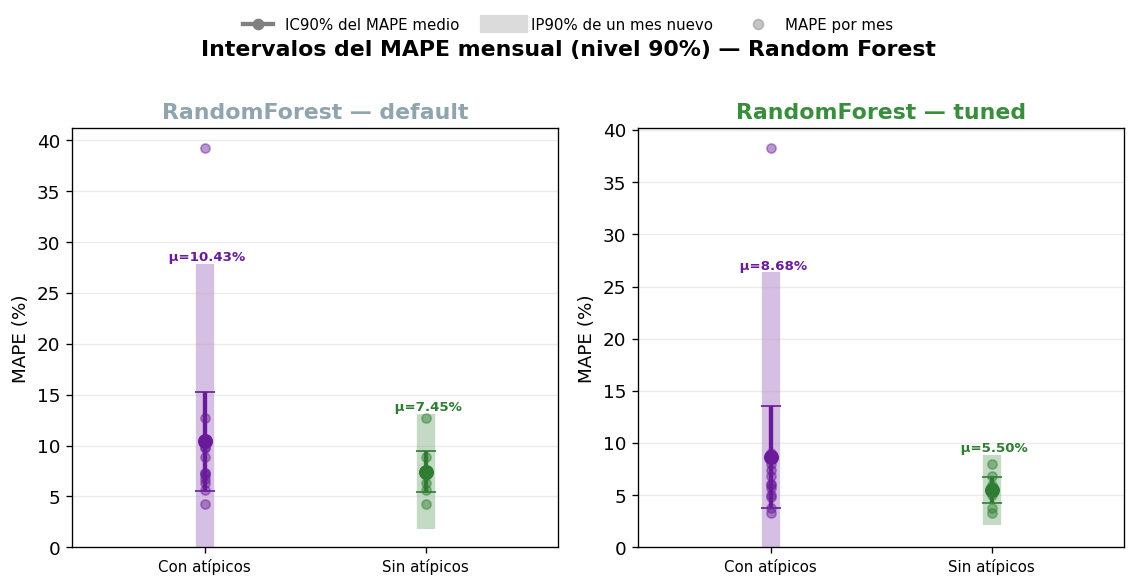

In [ ]:
# ── A · Intervalo de confianza / predicción del MAPE mensual ─────────────────
Z   = CI_LEVEL
pct = int(round(Z * 100))

def _mape_por_mes(variant, meses):
    return np.array([results[m][variant]['metrics']['MAPE (%)'] for m in meses], dtype=float)

def _intervalos_mape(vals, level=Z):
    n = len(vals)
    mean = float(np.mean(vals)); med = float(np.median(vals))
    sd   = float(np.std(vals, ddof=1)) if n > 1 else 0.0
    out = {'n': n, 'media': mean, 'mediana': med, 'std': sd,
           'min': float(np.min(vals)), 'max': float(np.max(vals)),
           'ic_media': (mean, mean), 'ip_mes': (mean, mean)}
    if n > 1:
        t = float(stats.t.ppf(0.5 + level/2, df=n-1)); se = sd/np.sqrt(n)
        out['ic_media'] = (mean - t*se,                  mean + t*se)
        out['ip_mes']   = (mean - t*sd*np.sqrt(1 + 1/n), mean + t*sd*np.sqrt(1 + 1/n))
    return out

_escenarios = {'Con at\u00edpicos': TEST_MONTHS, 'Sin at\u00edpicos': STABLE_MONTHS}
_store, _rows = {}, []
for variant in VARIANTS:
    _store[variant] = {}
    for esc, meses in _escenarios.items():
        vals = _mape_por_mes(variant, meses); s = _intervalos_mape(vals)
        _store[variant][esc] = {'vals': vals, **s}
        ic = (max(0.0, s['ic_media'][0]), s['ic_media'][1])
        ip = (max(0.0, s['ip_mes'][0]),   s['ip_mes'][1])
        _rows.append({'Variante': variant, 'Escenario': esc, 'n': s['n'],
                      'MAPE medio': round(s['media'], 2), 'MAPE mediana': round(s['mediana'], 2),
                      'std': round(s['std'], 2), 'min': round(s['min'], 2), 'max': round(s['max'], 2),
                      f'IC{pct}% media': f"[{ic[0]:.2f}, {ic[1]:.2f}]",
                      f'IP{pct}% un mes': f"[{ip[0]:.2f}, {ip[1]:.2f}]"})

ic_mape_df = pd.DataFrame(_rows)
print(f"{'\u2550'*70}\n  INTERVALOS DEL MAPE MENSUAL  (nivel {pct}%)\n{'\u2550'*70}")
print(ic_mape_df.to_string(index=False))
ic_mape_df.to_csv('intervalos_mape_rf.csv', index=False)
print("\n\u2192 Guardado: intervalos_mape_rf.csv")

# Gráfica: IC del MAPE medio (barra fuerte) + IP de un mes (barra ancha clara), por variante
fig, axes = plt.subplots(1, len(VARIANTS), figsize=(4.8*len(VARIANTS), 4.6), sharex=False)
if len(VARIANTS) == 1: axes = [axes]
offsets = {'Con at\u00edpicos': 0.0, 'Sin at\u00edpicos': 1.0}
ecolor  = {'Con at\u00edpicos': '#6A1B9A', 'Sin at\u00edpicos': '#2E7D32'}
for ax, variant in zip(axes, VARIANTS):
    for esc in _escenarios:
        s = _store[variant][esc]; x = offsets[esc]; m = s['media']
        ic = (max(0.0, s['ic_media'][0]), s['ic_media'][1])
        ip = (max(0.0, s['ip_mes'][0]),   s['ip_mes'][1])
        ax.scatter(np.full(len(s['vals']), x), s['vals'], color=ecolor[esc], alpha=0.45, s=30, zorder=2)
        ax.errorbar(x, m, yerr=[[m-ip[0]], [ip[1]-m]], fmt='none', ecolor=ecolor[esc],
                    alpha=0.28, elinewidth=11, zorder=1)
        ax.errorbar(x, m, yerr=[[m-ic[0]], [ic[1]-m]], fmt='o', color=ecolor[esc],
                    ecolor=ecolor[esc], elinewidth=2.6, capsize=6, ms=8, zorder=3)
        ax.text(x, ip[1], f' \u03bc={m:.2f}%', va='bottom', ha='center',
                fontsize=8, color=ecolor[esc], fontweight='bold')
    ax.set_xticks(list(offsets.values())); ax.set_xticklabels(list(offsets.keys()), fontsize=9)
    ax.set_xlim(-0.6, 1.6); ax.set_ylim(bottom=0)
    ax.set_title(f'RandomForest \u2014 {variant}', fontweight='bold', color=VCOLORS[variant])
    ax.set_ylabel('MAPE (%)'); ax.grid(True, axis='y', alpha=0.25)
handles = [Line2D([0],[0], color='gray', lw=2.6, marker='o', label=f'IC{pct}% del MAPE medio'),
           Line2D([0],[0], color='gray', lw=11, alpha=0.28, label=f'IP{pct}% de un mes nuevo'),
           Line2D([0],[0], color='gray', lw=0, marker='o', alpha=0.45, label='MAPE por mes')]
fig.legend(handles=handles, loc='upper center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, 1.07), frameon=False)
plt.suptitle(f'Intervalos del MAPE mensual (nivel {pct}%) \u2014 Random Forest', fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('intervalos_mape_rf.png', dpi=150, bbox_inches='tight')
plt.show()


Recolectando residuos out-of-sample de walk-forward CV (RF tuneado)…
  n calibración = 366  (2024-01 … 2024-12, atípicos excluidos)


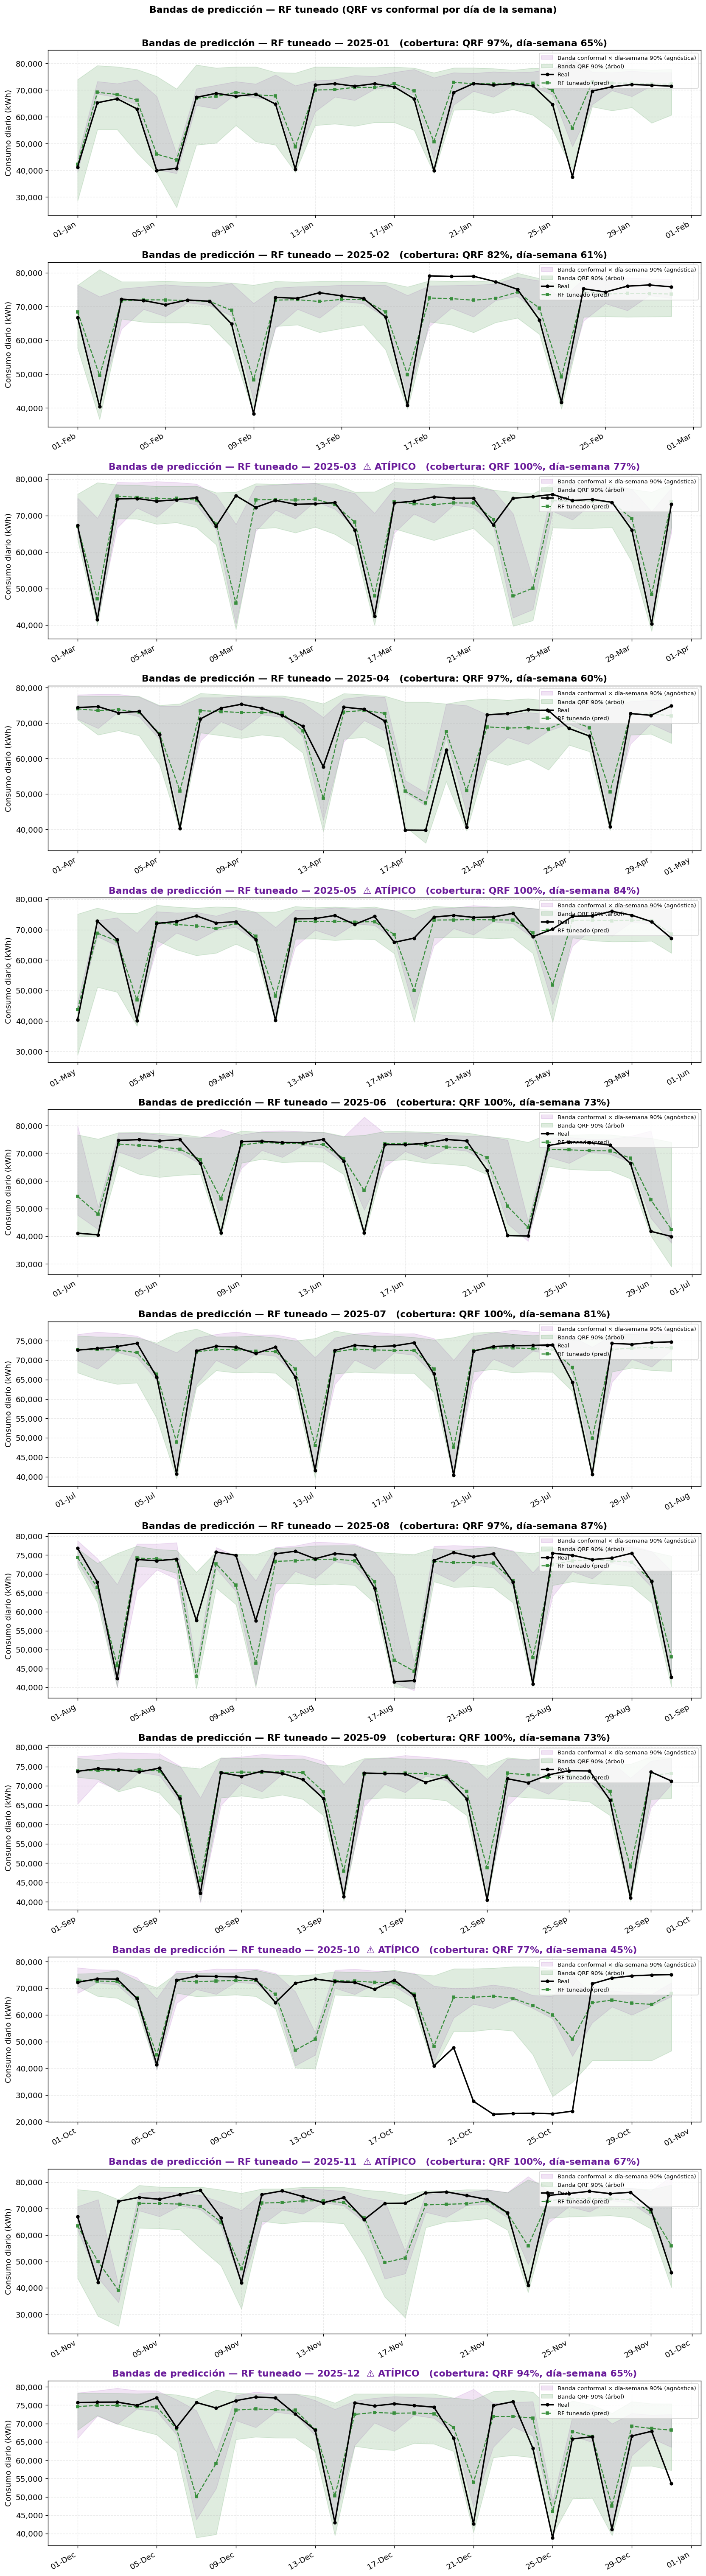


══ Cobertura empírica 90% (meses estables) ══
  QRF (árbol)            : cobertura media = 96.1%
  Conformal × día-semana : cobertura media = 71.4%  (objetivo 90%)
  → La banda agnóstica usa la MISMA función que aplicarás al SARIMAX (mismo criterio de cobertura).


In [ ]:
# ── B · Dos bandas alrededor del pronóstico diario (RF tuneado) ──────────────
#   (1) QRF          → específica del árbol (cuantiles reales de las hojas del bosque)
#   (2) Weekday-conf → agnóstica y PORTABLE a SARIMAX (solo usa pred y real de calibración)
PI = CI_LEVEL
q_lo, q_hi = (1 - PI) / 2, 1 - (1 - PI) / 2

# ═════════════════════════════════════════════════════════════════════════════
# (1) BANDA POR QUANTILE REGRESSION FORESTS  (Meinshausen 2006) — solo RF
#     Para cada punto de test se acumulan los y de entrenamiento que caen en sus
#     mismas hojas (ponderados) y se leen cuantiles reales de esa distribución.
# ═════════════════════════════════════════════════════════════════════════════
def _weighted_quantile(values, quantiles, weights):
    values = np.asarray(values, float); weights = np.asarray(weights, float)
    order = np.argsort(values, kind='stable')
    v, w = values[order], weights[order]
    cw = np.cumsum(w)
    if cw[-1] <= 0:
        return np.quantile(values, quantiles)
    cw = cw / cw[-1]
    return np.interp(quantiles, cw, v)

def _qrf_quantiles(model, Xtr_imp, ytr, Xte_imp, quantiles):
    ytr = np.asarray(ytr, float)
    tr_leaves = model.apply(Xtr_imp)      # (n_tr, n_trees)
    te_leaves = model.apply(Xte_imp)      # (n_te, n_trees)
    n_tr, n_trees = tr_leaves.shape
    n_te = te_leaves.shape[0]
    tree_maps = []                        # por árbol: hoja -> índices de train en esa hoja
    for t in range(n_trees):
        col = tr_leaves[:, t]; order = np.argsort(col, kind='stable')
        cs = col[order]; uniq, starts = np.unique(cs, return_index=True)
        bounds = np.append(starts, len(cs))
        tree_maps.append({int(l): order[bounds[k]:bounds[k+1]] for k, l in enumerate(uniq)})
    out = np.zeros((len(quantiles), n_te))
    for j in range(n_te):
        w = np.zeros(n_tr)
        for t in range(n_trees):
            idx = tree_maps[t].get(int(te_leaves[j, t]))
            if idx is not None and len(idx):
                w[idx] += 1.0 / len(idx)
        out[:, j] = _weighted_quantile(ytr, quantiles, w)
    return out

def banda_qrf(mes, level=PI):
    ql, qh = (1 - level) / 2, 1 - (1 - level) / 2
    model = results[mes]['tuned']['model']; imp = model._imputer
    cutoff = pd.Timestamp(f'{mes}-01'); end = cutoff + MonthEnd(1)
    train = df[df.index < cutoff]
    test  = df[(df.index >= cutoff) & (df.index <= end)]
    Xtr = imp.transform(train[FEATURES_TREE]); ytr = train['Consumo'].to_numpy(float)
    Xte = imp.transform(mask_invalid_lags(test[FEATURES_TREE]))
    lo, hi = _qrf_quantiles(model, Xtr, ytr, Xte, [ql, qh])
    return lo, hi

# ═════════════════════════════════════════════════════════════════════════════
# (2) BANDA CONFORMAL SPLIT CONDICIONADA POR DÍA DE LA SEMANA — agnóstica
#     PORTABLE: copia esta misma función al notebook de SARIMAX. Solo necesita
#     (fechas, real, pred) de calibración y (fechas, pred) del target.
#     No se condiciona por horizonte (aquí apenas afecta la calidad).
# ═════════════════════════════════════════════════════════════════════════════
def weekday_conformal_bands(cal_dates, cal_real, cal_pred,
                            target_dates, target_pred,
                            level=PI, mode='relative', min_group=15):
    a = 1 - level; ql, qh = a / 2, 1 - a / 2
    cal_real = np.asarray(cal_real, float); cal_pred = np.asarray(cal_pred, float)
    cal_wd = pd.DatetimeIndex(cal_dates).weekday.to_numpy()
    if mode == 'relative':
        ok = cal_pred != 0
        resid  = (cal_real[ok] - cal_pred[ok]) / cal_pred[ok]
        cal_wd = cal_wd[ok]
    else:  # 'absolute'
        resid = cal_real - cal_pred
    g_lo, g_hi = np.quantile(resid, ql), np.quantile(resid, qh)      # respaldo global
    lo_wd, hi_wd = {}, {}
    for w in range(7):
        r = resid[cal_wd == w]
        if len(r) >= min_group:
            lo_wd[w], hi_wd[w] = np.quantile(r, ql), np.quantile(r, qh)
        else:
            lo_wd[w], hi_wd[w] = g_lo, g_hi                          # weekday con pocos datos -> global
    tp  = np.asarray(target_pred, float)
    twd = pd.DatetimeIndex(target_dates).weekday.to_numpy()
    lo  = np.array([lo_wd[w] for w in twd]); hi = np.array([hi_wd[w] for w in twd])
    if mode == 'relative':
        return tp * (1 + lo), tp * (1 + hi)
    return tp + lo, tp + hi

# Calibración: residuos out-of-sample del RF tuneado sobre los folds CV (un año) ──
def collect_cv_oos_rf(params, cv_months):
    D, R, P = [], [], []
    for mes in cv_months:
        cutoff = pd.Timestamp(f'{mes}-01'); end = cutoff + MonthEnd(1)
        tr  = df[df.index < cutoff]
        val = df[(df.index >= cutoff) & (df.index <= end)]
        if len(tr) < 365 or len(val) == 0:
            continue
        Xtr, ytr = tr[FEATURES_TREE], tr['Consumo']
        Xv_m, yv = mask_invalid_lags(val[FEATURES_TREE]), val['Consumo']
        try:
            preds, _ = fit_predict_rf(params, Xtr, ytr, Xv_m)
            D.extend(list(val.index)); R.extend(list(yv.values)); P.extend(list(np.asarray(preds, float)))
        except Exception:
            continue
    return pd.DatetimeIndex(D), np.array(R, float), np.array(P, float)

CAL_MODE = 'relative'   # 'relative' (multiplicativo, se adapta al nivel) | 'absolute' (aditivo)
print("Recolectando residuos out-of-sample de walk-forward CV (RF tuneado)…")
cal_D, cal_R, cal_P = collect_cv_oos_rf(best_params_rf, CV_MONTHS)
print(f"  n calibración = {len(cal_R)}  ({CV_MONTHS[0]} … {CV_MONTHS[-1]}, atípicos excluidos)")

def banda_weekday(mes):
    rr = results[mes]['tuned']
    return weekday_conformal_bands(cal_D, cal_R, cal_P, rr['dates'], rr['preds'],
                                   level=PI, mode=CAL_MODE)

# Cache para no recalcular QRF dos veces (gráfica + cobertura) ────────────────
_band_cache = {}
def get_bands(mes):
    if mes not in _band_cache:
        _band_cache[mes] = {'qrf': banda_qrf(mes), 'wd': banda_weekday(mes)}
    return _band_cache[mes]

# ── Gráfica: las dos bandas por mes ──────────────────────────────────────────
n = len(PLOT_MONTHS)
fig, axes = plt.subplots(n, 1, figsize=(14, 4.2*n), sharex=False)
if n == 1: axes = [axes]
for ax, mes in zip(axes, PLOT_MONTHS):
    rr = results[mes]['tuned']
    dates, real, pred = rr['dates'], rr['real'], np.asarray(rr['preds'], float)
    b = get_bands(mes); lo_q, hi_q = b['qrf']; lo_w, hi_w = b['wd']
    ax.fill_between(dates, lo_w, hi_w, color='#8E24AA', alpha=0.12,
                    label=f'Banda conformal × día-semana {int(PI*100)}% (agnóstica)')
    ax.fill_between(dates, lo_q, hi_q, color='#388E3C', alpha=0.16,
                    label=f'Banda QRF {int(PI*100)}% (árbol)')
    ax.plot(dates, real, 'k-o', lw=2, ms=4, label='Real', zorder=6)
    ax.plot(dates, pred, '--s', ms=3.5, lw=1.5, color='#388E3C', label='RF tuneado (pred)', zorder=5)
    cov_q = float(np.mean((real >= lo_q) & (real <= hi_q))) * 100
    cov_w = float(np.mean((real >= lo_w) & (real <= hi_w))) * 100
    tag = '  ⚠ ATÍPICO' if is_atyp(mes) else ''
    ax.set_title(f'Bandas de predicción — RF tuneado — {mes}{tag}   '
                 f'(cobertura: QRF {cov_q:.0f}%, día-semana {cov_w:.0f}%)',
                 fontweight='bold', color=('#6A1B9A' if is_atyp(mes) else 'black'))
    ax.set_ylabel('Consumo diario (kWh)'); ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25, ls='--')
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d-%b'))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.suptitle('Bandas de predicción — RF tuneado (QRF vs conformal por día de la semana)',
             fontweight='bold', y=1.003)
plt.tight_layout()
plt.savefig('bandas_prediccion_rf.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Cobertura empírica sobre meses estables (objetivo = nivel nominal) ────────
print(f"\n══ Cobertura empírica {int(PI*100)}% (meses estables) ══")
cov_q_all, cov_w_all = [], []
for mes in STABLE_MONTHS:
    real = results[mes]['tuned']['real']
    b = get_bands(mes); lq, hq = b['qrf']; lw, hw = b['wd']
    cov_q_all.append(float(np.mean((real >= lq) & (real <= hq))))
    cov_w_all.append(float(np.mean((real >= lw) & (real <= hw))))
if cov_q_all:
    print(f"  QRF (árbol)            : cobertura media = {np.mean(cov_q_all)*100:.1f}%")
    print(f"  Conformal × día-semana : cobertura media = {np.mean(cov_w_all)*100:.1f}%  (objetivo {int(PI*100)}%)")
    print("  → La banda agnóstica usa la MISMA función que aplicarás al SARIMAX (mismo criterio de cobertura).")
else:
    print("  (sin meses estables)")


## 19. Resumen sobre meses estables y exportación

In [ ]:
# ── Resumen (solo meses estables) ────────────────────────────────────────────
summary_rows = []
for variant in VARIANTS:
    a = _avg_metrics(variant, STABLE_MONTHS)
    summary_rows.append({'Variante': variant, 'MAE': round(a['MAE'], 0), 'RMSE': round(a['RMSE'], 0),
                         'MAPE (%)': round(a['MAPE (%)'], 2), 'R²': round(a['R²'], 4)})
summary_stable = pd.DataFrame(summary_rows).set_index('Variante')
d_mape = summary_stable.loc['default', 'MAPE (%)']; t_mape = summary_stable.loc['tuned', 'MAPE (%)']
print("══ RESUMEN — MESES ESTABLES (Random Forest) ══")
print(summary_stable.to_string())
print(f"\n→ MAPE default = {d_mape:.2f}%  →  tuneado = {t_mape:.2f}%  "
      f"(mejora {(d_mape-t_mape)/d_mape*100:+.1f}%)")

# ── Predicciones día a día (default + tuned, con flag de atípico) ─────────────
all_rows = []
for mes in TEST_MONTHS:
    for variant in VARIANTS:
        r = results[mes][variant]
        for date, pred, real_v in zip(r['dates'], r['preds'], r['real']):
            pred = float(pred)
            all_rows.append({'Fecha': date.date(), 'Mes': mes, 'Atipico': is_atyp(mes),
                             'Variante': variant, 'Real': real_v, 'Prediccion': round(pred, 2),
                             'AbsError': round(abs(real_v - pred), 2),
                             'APE (%)': round(abs(real_v - pred)/real_v*100, 4) if real_v != 0 else None})
preds_df = pd.DataFrame(all_rows)
preds_df.to_csv('predicciones_rf.csv', index=False)

# ── Métricas completas + tuning + params ─────────────────────────────────────
metrics_df.to_csv('metricas_rf.csv', index=False)
tuning_df.to_csv('tuning_rf.csv', index=False)
summary_stable.to_csv('resumen_meses_estables_rf.csv')
with open('best_params_rf.json', 'w') as f:
    json.dump({'default': DEFAULT_RF, 'tuned': best_params_rf,
               'best_known': RF_BEST_KNOWN,
               'search_n_estimators': SEARCH_N_ESTIMATORS, 'final_n_estimators': FINAL_N_ESTIMATORS,
               'cv_known': known_stats, 'cv_tuned': best_stats}, f, indent=2, default=str)

print("\nArchivos exportados:")
print("  predicciones_rf.csv             — predicciones día a día (default + tuned)")
print("  metricas_rf.csv                 — MAE/RMSE/MAPE/R² por mes y variante")
print("  tuning_rf.csv                   — historial de la búsqueda guiada")
print("  intervalos_mape_rf.csv          — intervalos del MAPE mensual")
print("  feature_importance_perm_rf.csv  — importancia por permutación (out-of-sample)")
print("  resumen_meses_estables_rf.csv   — resumen promediado sobre meses estables")
print("  best_params_rf.json             — default / tuned / best-known + scores CV")
print(f"\n{preds_df.head(8).to_string(index=False)}")


══ RESUMEN — MESES ESTABLES (Random Forest) ══
             MAE    RMSE  MAPE (%)      R²
Variante                                  
default   3833.0  5521.0      7.45  0.7890
tuned     2841.0  4284.0      5.50  0.8733

→ MAPE default = 7.45%  →  tuneado = 5.50%  (mejora +26.2%)

Archivos exportados:
  predicciones_rf.csv             — predicciones día a día (default + tuned)
  metricas_rf.csv                 — MAE/RMSE/MAPE/R² por mes y variante
  tuning_rf.csv                   — historial de la búsqueda guiada
  intervalos_mape_rf.csv          — intervalos del MAPE mensual
  feature_importance_perm_rf.csv  — importancia por permutación (out-of-sample)
  resumen_meses_estables_rf.csv   — resumen promediado sobre meses estables
  best_params_rf.json             — default / tuned / best-known + scores CV

     Fecha     Mes  Atipico Variante    Real  Prediccion  AbsError  APE (%)
2025-01-01 2025-01    False  default 41255.5    53624.05  12368.55  29.9804
2025-01-02 2025-01    False  de